# 🏠 House Price Prediction
### Internship Project — Week 1

**Goal:** Build a regression model that predicts house prices from property features (area, rooms, location-type amenities, etc.) and identify which features influence price the most.

**Dataset:** `Housing.csv` — 545 houses, 13 columns (Kaggle: *Housing Prices Dataset*)

**Workflow:**
1. Data Loading & Exploration
2. Data Cleaning
3. Model Building (Linear Regression vs Random Forest)
4. Visualization
5. Insights & Summary


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make charts look clean by default
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

import os
os.makedirs("charts", exist_ok=True)

## Task 1 — Data Loading & Exploration

In [2]:
# Load the dataset (place Housing.csv in the same folder as this notebook)
df = pd.read_csv("Housing.csv")

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

Dataset shape: 545 rows, 13 columns


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()
print("Column names:")
print(df.columns.tolist())

Rows: 545
Columns: 13

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [4]:
# Data types — useful to know which columns are numeric vs categorical (yes/no text)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


**Target column:** `price` — this is what we want to predict.

**Feature columns:** everything else — `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus`.

In [5]:
target = "price"
features = df.drop(columns=[target]).columns.tolist()

print("Target column:", target)
print("\nFeature columns:")
for f in features:
    print(" -", f)

Target column: price

Feature columns:
 - area
 - bedrooms
 - bathrooms
 - stories
 - mainroad
 - guestroom
 - basement
 - hotwaterheating
 - airconditioning
 - parking
 - prefarea
 - furnishingstatus


In [6]:
# Check for missing values in each column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

if missing.sum() == 0:
    print("\n✅ No missing values found in the dataset.")

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

✅ No missing values found in the dataset.


In [7]:
# Quick statistical summary of numeric columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Task 2 — Data Cleaning

This dataset is already quite clean (no missing values), but we still follow the full cleaning checklist:
1. Handle missing values (none found, but the code below would handle them if present)
2. Remove duplicate rows
3. Convert categorical (yes/no and multi-class) columns into numeric form
4. Keep only meaningful columns for modeling


In [8]:
# 1) Handle missing values, in case any exist
#    - Numeric columns: fill with the column median (robust to outliers)
#    - Categorical columns: fill with the most frequent value (mode)
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [9]:
# 2) Remove duplicate rows, if any
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"Rows before removing duplicates: {before}")
print(f"Rows after removing duplicates:  {after}")
print(f"Duplicate rows removed: {before - after}")

Rows before removing duplicates: 545
Rows after removing duplicates:  545
Duplicate rows removed: 0


In [10]:
# 3) Convert categorical columns into numeric form
# This dataset has two kinds of categorical columns:
#   a) Simple yes/no columns        -> map to 1/0
#   b) Multi-class column           -> one-hot encode ('furnishingstatus')

binary_cols = [c for c in categorical_cols if set(df[c].dropna().unique()) <= {"yes", "no"}]
print("Binary (yes/no) columns:", binary_cols)

for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# One-hot encode the remaining multi-class categorical column(s)
df_model = pd.get_dummies(df, drop_first=True)

print("\nColumns after encoding:")
print(df_model.columns.tolist())
df_model.head()

Binary (yes/no) columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


**4) Keep only meaningful columns** — every remaining column (area, bedrooms, bathrooms, stories, parking, and all the yes/no amenities + furnishing status) is a reasonable, interpretable driver of price, so we keep all of them for modeling. No columns are pure identifiers or irrelevant text, so nothing needs to be dropped here.

## Task 3 — Model Building

In [11]:
# Split features (X) and target (y)
X = df_model.drop(columns=["price"])
y = df_model["price"]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

Training set size: (436, 13)
Test set size:     (109, 13)


### Model 1 — Linear Regression

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print(f"  MAE  : {lr_mae:,.0f}")
print(f"  RMSE : {lr_rmse:,.0f}")
print(f"  R2   : {lr_r2:.3f}")

Linear Regression Results
  MAE  : 970,043
  RMSE : 1,324,507
  R2   : 0.653


### Model 2 — Random Forest Regressor

In [13]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print(f"  MAE  : {rf_mae:,.0f}")
print(f"  RMSE : {rf_rmse:,.0f}")
print(f"  R2   : {rf_r2:.3f}")

Random Forest Results
  MAE  : 1,019,598
  RMSE : 1,399,213
  R2   : 0.613


### Model Comparison

In [14]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R2 Score": "{:.3f}"})

,Model,MAE,RMSE,R2 Score
0,Linear Regression,"970,043","1,324,507",0.653
1,Random Forest,"1,019,598","1,399,213",0.613


**Reading the comparison:** lower MAE/RMSE = smaller average error in rupees; higher R² = more of the variation in price explained by the model (closer to 1.0 is better). With only ~545 rows and mostly linear/monotonic relationships (bigger house → higher price), a simple Linear Regression model can hold its own against Random Forest — tree-based models usually need more data and more non-linear patterns to pull ahead.

## Task 4 — Visualization

### Chart 1 — Distribution of House Prices

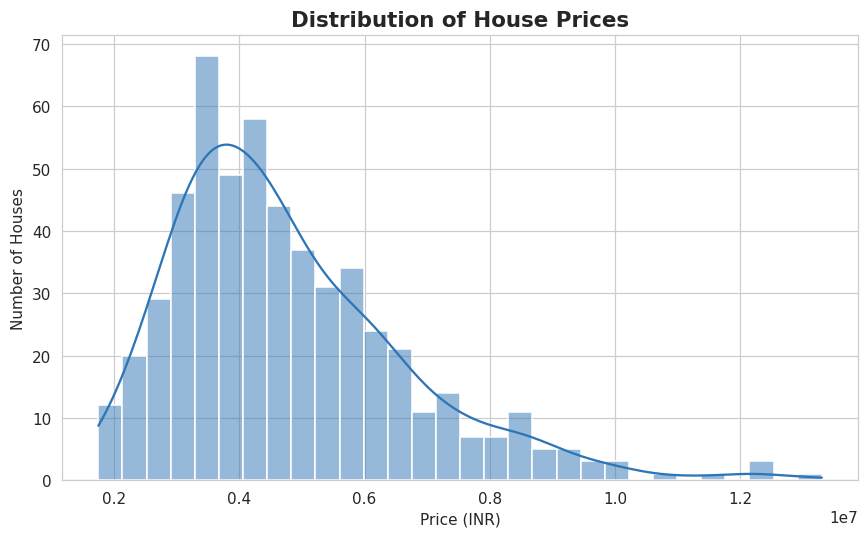

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="#2E75B6")
plt.title("Distribution of House Prices", fontsize=14, fontweight="bold")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.savefig("charts/1_price_distribution.png", dpi=150)
plt.show()

The distribution is **right-skewed** — most houses are priced between roughly ₹30 lakh and ₹70 lakh, with a smaller number of expensive outliers stretching the tail out toward ₹1.3 crore.

### Chart 2 — Correlation Heatmap

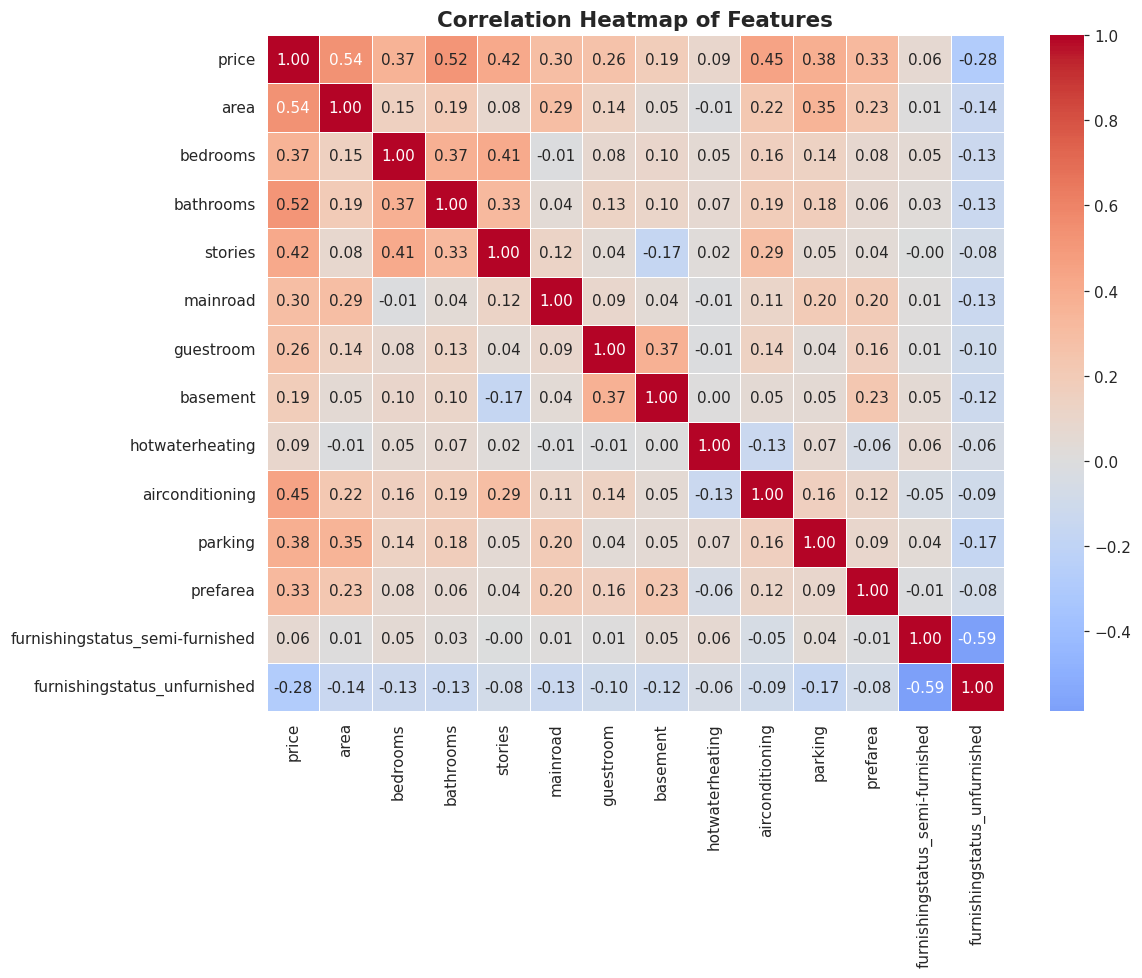

In [16]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    df_model.corr(numeric_only=True),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5
)
plt.title("Correlation Heatmap of Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/2_correlation_heatmap.png", dpi=150)
plt.show()

In [17]:
# Features most correlated with price, ranked
corr_with_price = df_model.corr(numeric_only=True)["price"].drop("price").sort_values(ascending=False)
corr_with_price

area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

`area`, `bathrooms`, `airconditioning`, and `stories` show the strongest positive correlation with price. `furnishingstatus_unfurnished` is the only clearly negative correlation — unfurnished homes tend to sell for less.

### Chart 3 — Actual vs Predicted Prices (creative chart)

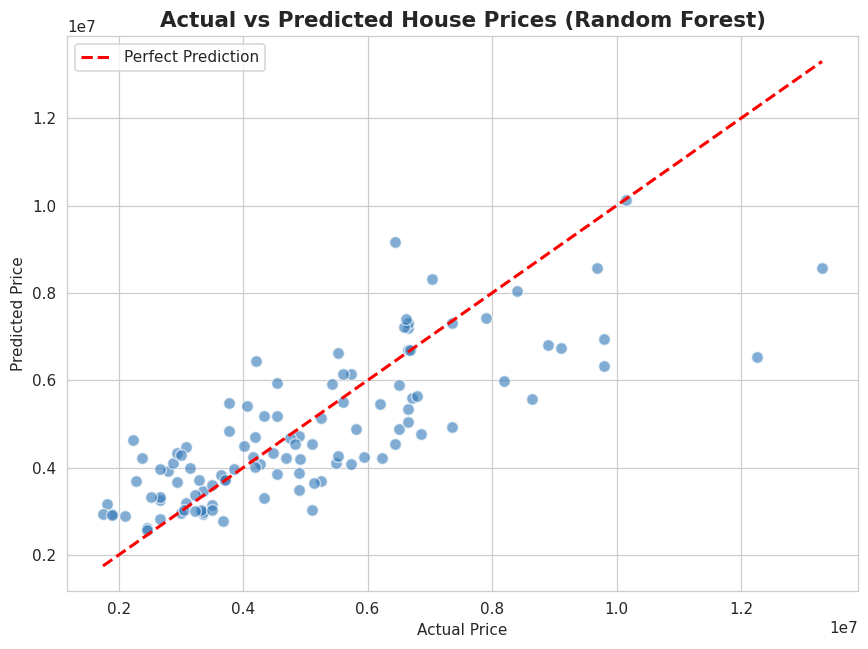

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.6, color="#2E75B6", edgecolor="white", s=60)

lims = [min(y_test.min(), rf_pred.min()), max(y_test.max(), rf_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Random Forest)", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("charts/3_actual_vs_predicted.png", dpi=150)
plt.show()

Points sitting close to the red dashed line are accurate predictions. The model does well for mid-range homes (₹30–70 lakh) but is less precise at the high end, where prices are more driven by unique, hard-to-quantify factors (exact location, finishing quality, negotiation, etc.).

### Bonus Chart — Top Features Driving Price (Random Forest importance)

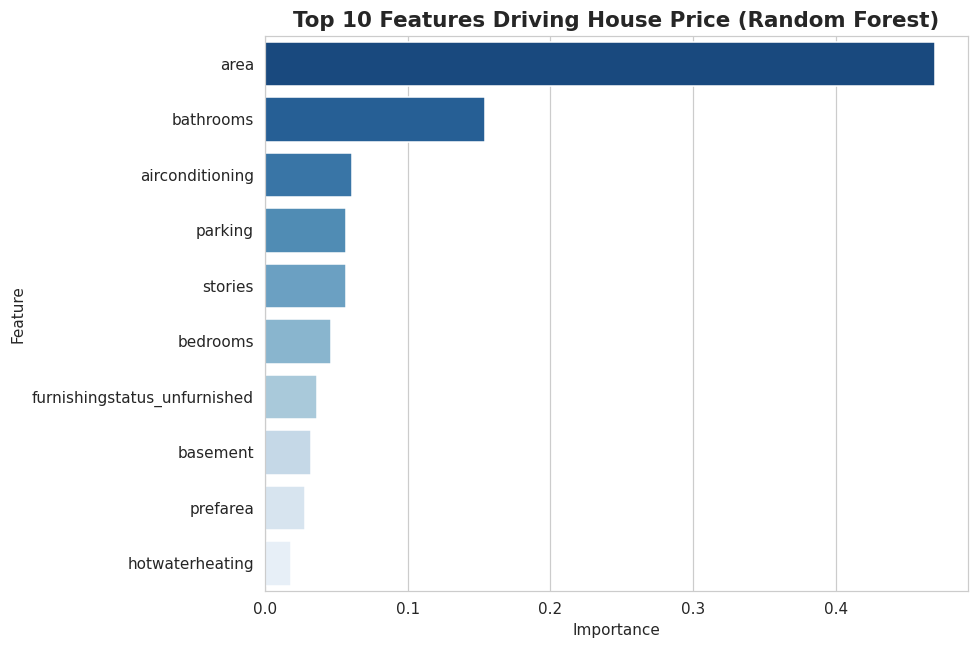

,Feature,Importance
0,area,0.468947
2,bathrooms,0.154518
8,airconditioning,0.061262
9,parking,0.056642
3,stories,0.056639
1,bedrooms,0.046641
12,furnishingstatus_unfurnished,0.036882
6,basement,0.032602
10,prefarea,0.028476
7,hotwaterheating,0.018419


In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x="Importance", y="Feature", hue="Feature", data=importance.head(10), legend=False, palette="Blues_r")
plt.title("Top 10 Features Driving House Price (Random Forest)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/4_feature_importance.png", dpi=150)
plt.show()

importance.head(10)

## Task 5 — Insights & Summary

**Which features influence price the most?**
`area` is by far the strongest driver of price, followed by `bathrooms`, `airconditioning`, and the number of `stories`. Together these explain most of the price variation — bigger, more amenity-rich houses simply cost more.

**How accurate was the model, in plain terms?**
Linear Regression explained about 65% of the variation in price (R² ≈ 0.65) with an average error of roughly ₹9.7 lakh, while Random Forest landed in a similar range (R² ≈ 0.61, average error ≈ ₹10.2 lakh). In practice this means the model gets the general price range right for most homes, but on a dataset this small (545 rows) neither model is precise enough to replace a real valuation — it's a solid first-pass estimator, not a final price.

**What was surprising?**
Random Forest did **not** clearly beat Linear Regression here, which goes against the common assumption that "fancier models always win." With only ~545 rows and mostly straightforward, near-linear relationships (more area → more bathrooms → higher price), the simpler model generalizes just as well. It was also notable that `airconditioning` mattered almost as much as `stories`, and that unfurnished homes were consistently cheaper than semi-furnished or furnished ones.

**Recommendation for a real estate business:**
Prioritize marketing and pricing strategy around `area`, `bathrooms`, and `air conditioning` — these are the biggest, most controllable levers on perceived value. For renovation or staging budgets, adding air conditioning or upgrading furnishing status appears to offer a better price lift than smaller cosmetic changes.